In [1]:
import os
import numpy as np
import cv2
import random
from matplotlib import pyplot as plt

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
POS_PATH = os.path.join('data', 'positive')
NEG_PATH = os.path.join('data', 'negative')
ANC_PATH = os.path.join('data', 'anchor')

In [5]:
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

In [6]:
!tar -xf lfw.tgz

In [9]:
for directory in os.listdir('lfw'):
    for file in os.listdir(os.path.join('lfw', directory)):
        EX_PATH = os.path.join('lfw', directory, file)
        NEW_PATH = os.path.join(NEG_PATH, file)
        os.replace(EX_PATH, NEW_PATH)

In [5]:
# import uuid library to generate unique image names
import uuid

In [7]:
cap = cv2.VideoCapture(1)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250, 200:200+250, :]
    
    cv2.imshow('image collection', frame)
    
    # Collect Anchors    
    if cv2.waitKey(1) & 0XFF == ord('a'):
        imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    
    # Collect Positives
    if cv2.waitKey(1) & 0XFF == ord('p'):
        imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
        cv2.imwrite(imgname, frame)
    
    if cv2.waitKey(1) & 0XFF == ord('q'):
        break
        
cap.release()
cv2.destroyAllWindows()

In [6]:
anchor = tf.data.Dataset.list_files(ANC_PATH+'\*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH+'\*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH+'\*.jpg').take(300)

In [9]:
test = anchor.as_numpy_iterator()

In [10]:
test.next()

b'data\\anchor\\6d9ded08-2c15-11ec-8bf1-30e37a77a37f.jpg'

In [7]:
def preprocess(file_path):
    # read in image from file path
    byte_img = tf.io.read_file(file_path)
    # load in the image
    img = tf.io.decode_jpeg(byte_img)
    # preprocessing steps - resizing the image to be 105x105x3
    img = tf.image.resize(img, (105,105))
    # scale img to be between 0 and 1
    img = img / 255.0
    return img

In [14]:
img = preprocess('data\\anchor\\6d9ded08-2c15-11ec-8bf1-30e37a77a37f.jpg')

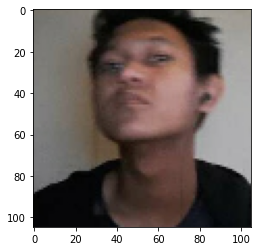

In [15]:
plt.imshow(img)

In [21]:
# (anchor, positive) => 1,1,1,1,1
# (anchor, negative) => 0,0,0,0,0

In [8]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [17]:
samples = data.as_numpy_iterator()

In [18]:
test = samples.next()

In [9]:
def preprocess_twin(input_img, validation_img, label):
    return(preprocess(input_img), preprocess(validation_img), label)

In [20]:
res = preprocess_twin(*test)

In [21]:
res[2]

1.0

In [10]:
# Build dataloader pipeline
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [11]:
# Training partition
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [24]:
train_data

<PrefetchDataset shapes: ((None, 105, 105, None), (None, 105, 105, None), (None,)), types: (tf.float32, tf.float32, tf.float32)>

In [25]:
train_samples = train_data.as_numpy_iterator()

In [26]:
train_sample = train_samples.next()

In [27]:
len(train_sample[1])

16

In [12]:
# Testing partition
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = train_data.prefetch(8)

In [13]:
# build embedding layer

def make_embedding():
    inp = Input(shape=(105,105,3), name='input_image')
    
    # first block
    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)
    
    # second block
    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)
    
    # third block
    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)
    
    
    # final embedding block
    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)
    
    
    return Model(inputs=[inp], outputs=[d1], name='embedding')

In [14]:
embedding = make_embedding()

In [15]:
embedding.summary()

Model: "embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 105, 105, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 96, 96, 64)        19264     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 48, 48, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 42, 42, 128)       401536    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 21, 21, 128)       0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 18, 18, 128)       262272    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 9, 9, 128)         0 

In [16]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__()
    
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [54]:
# Make siamese model

In [33]:
input_image = Input(name='input_img', shape=(105,105,3))
validation_image = Input(name='validation_img', shape=(105,105,3))

In [34]:
inp_embedding = embedding(input_image)
val_embedding = embedding(validation_image)

In [35]:
siamese_layer = L1Dist()

In [36]:
distances = siamese_layer(inp_embedding, val_embedding)

In [37]:
classifier = Dense(1, activation='sigmoid')(distances)

In [38]:
siamese_network = Model(inputs=[input_image, validation_image], outputs=[classifier], name='SiameseNetwork')

In [39]:
siamese_network.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist (L1Dist)                (None, 4096)         0           embedding[0][0]     

In [17]:
def make_siamese_model():
    # Anchor img input
    input_image = Input(name='input_img', shape=(105,105,3))
    
    # Validation image in the network
    validation_image = Input(name='validation_img', shape=(105,105,3))
    
    # Combine siamese distance components
    
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))
    
    # Classification layer
    
    classifier = Dense(1, activation='sigmoid')(distances)
    
    return Model(inputs=[input_image, validation_image], outputs=[classifier], name='SiameseNetwork')

In [18]:
siamese_model = make_siamese_model()

In [43]:
siamese_model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
distance (L1Dist)               (None, 4096)         0           embedding[2][0]     

In [ ]:
# Trainning Model

In [19]:
# Setup Loss and Optimizer
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [20]:
opt = tf.keras.optimizers.Adam(1e-4) #0.0001

In [21]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt, siamese_model=siamese_model)

In [22]:
@tf.function # compiling what is going to happen under train step
def train_step(batch):
    with tf.GradientTape() as tape:
        # Get anchor and positive/negative image
        X = batch[:2]
        # Get label
        y = batch[2]
        
        # Forward pass
        yhat = siamese_model(X, training=True)
        # Calculate loss
        loss = binary_cross_loss(y, yhat)
        
    print(loss)
        
    # Calculate gradients
    grad = tape.gradient(loss, siamese_model.trainable_variables)
    
    # Calculate updated weights and apply to siamese_model
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))
    
    return loss

In [23]:
def train(data, EPOCHS):
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print("\n Epoch {}/{}".format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
    
        # Loop through each batch
        for idx, batch in enumerate(data):
            train_step(batch)
            progbar.update(idx+1)

        # Save checkpoint
        if epoch % 10 == 0:
            checkpoint.save(file_prefix = checkpoint_prefix)


In [24]:
EPOCHS = 50 

In [25]:
train(train_data, EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
27/27 [==============================] - 31s 982ms/step

 Epoch 2/50
27/27 [==============================] - 26s 994ms/step

 Epoch 3/50
27/27 [==============================] - 26s 995ms/step

 Epoch 4/50
27/27 [==============================] - 26s 996ms/step

 Epoch 5/50
27/27 [==============================] - 26s 997ms/step

 Epoch 6/50
27/27 [==============================] - 26s 999ms/step

 Epoch 7/50
27/27 [==============================] - 26s 998ms/step

 Epoch 8/50
27/27 [==============================] - 26s 998ms/step

 Epoch 9/50
27/27 [==============================] - 26s 999ms/step

 Epoch 10/50
27/27 [==============================] - 26s 1s/step

 Epoch 11/50
27/27 [==============================] - 26s 1000ms/step

 Epoch 12/50
27/27 [==============================] - 26s 992ms/step

 Epoch 13/50
27/

In [ ]:
# Evaluate model

In [26]:
from tensorflow.keras.metrics import Precision, Recall

In [27]:
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [ ]:
# make prediction

In [28]:
y_hat = siamese_model.predict([test_input, test_val])
y_hat

array([[1.9933034e-06],
       [2.7694249e-09],
       [4.2550170e-08],
       [3.3809755e-08],
       [9.9978977e-01],
       [1.0000000e+00],
       [3.1580023e-09],
       [1.0000000e+00],
       [5.5191560e-07],
       [8.8368542e-05],
       [3.3050862e-06],
       [1.0000000e+00],
       [5.3951108e-08],
       [6.5693541e-08],
       [1.0000000e+00],
       [2.2071761e-05]], dtype=float32)

In [ ]:
# Post processing result

In [29]:
[1 if prediction > 0.5 else 0 for prediction in y_hat]

[0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0]

In [30]:
y_true

array([0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.],
      dtype=float32)

In [31]:
m = Recall()
m.update_state(y_true, y_hat)
m.result().numpy()

1.0

In [32]:
m = Precision()
m.update_state(y_true, y_hat)
m.result().numpy()

1.0

In [ ]:
# Visualize result

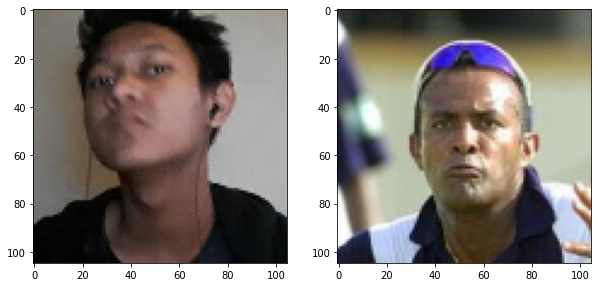

In [33]:
# Set plot size
plt.figure(figsize=(10,8))

# Set first subplot
plt.subplot(1,2,1)
plt.imshow(test_input[2])

# Set second subplot
plt.subplot(1,2,2)
plt.imshow(test_val[2])

# Renders cleanly
plt.show()

In [ ]:
# Save model

In [34]:
siamese_model.save('siamesemodel.h5')

In [35]:
# Reload model
model = tf.keras.models.load_model('siamesemodel.h5',
                                   custom_objects= {'L1Dist':L1Dist, 'BinaryCrossentropy':tf.losses.BinaryCrossentropy} ) 

In [36]:
model.predict([test_input, test_val])

array([[1.9933034e-06],
       [2.7694249e-09],
       [4.2550170e-08],
       [3.3809755e-08],
       [9.9978977e-01],
       [1.0000000e+00],
       [3.1580023e-09],
       [1.0000000e+00],
       [5.5191560e-07],
       [8.8368542e-05],
       [3.3050862e-06],
       [1.0000000e+00],
       [5.3951108e-08],
       [6.5693541e-08],
       [1.0000000e+00],
       [2.2071761e-05]], dtype=float32)

In [37]:
model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_img (InputLayer)          [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
validation_img (InputLayer)     [(None, 105, 105, 3) 0                                            
__________________________________________________________________________________________________
embedding (Functional)          (None, 4096)         38960448    input_img[0][0]                  
                                                                 validation_img[0][0]             
__________________________________________________________________________________________________
l1_dist_1 (L1Dist)              (None, 4096)         0           embedding[0][0]     

In [ ]:
# Real Time Test

In [ ]:
# Verification function

In [76]:
def verify(model, detection_threshold, verification_threshold):
    results = []
    for image in os.listdir(os.path.join('application_data', 'verification_images')):
        input_img = preprocess(os.path.join('application_data', 'input_image', 'input_image.jpg'))
        validation_img = preprocess(os.path.join('application_data', 'verification_images', image))
        
        result = model.predict(list(np.expand_dims([input_img, validation_img], axis=1)))
        results.append(result)
        
    # Detection threshold : Metric above a prediction is considered positive
    detection = np.sum(np.array(results) > detection_threshold)
    
    # Verification threshold : Proportion of positive predictions / total positive samples
    verification = detection / len(os.listdir(os.path.join('application_data', 'verification_images')))
    
    verified = verification > verification_threshold
    
    return results, verified
    


In [1]:
cap = cv2.VideoCapture(1)
while cap.isOpened():
    ret, frame = cap.read()
    frame = frame[120:120+250, 200:200+250, :]
    
    cv2.imshow('Verification', frame)
    
    # Verification trigger
    
    if cv2.waitKey(10) & 0xFF == ord('v'):
        # Save input image to application data - input_image
        cv2.imwrite(os.path.join('application_data','input_image', 'input_image.jpg'), frame)
        # Run verification
        results, verified = verify(model, 0.9, 0.7)
        print(verified)
     
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

NameError: name 'cv2' is not defined

In [89]:
results, verified = verify(model, 0.9, 0.7)
print(verified)

True
